# Diagram Sistem Dinamis: Pasar Ikan, Inflasi, dan Kemiskinan Sulawesi Tenggara

Notebook kelima ini menggambar struktur sebab-akibat yang dipakai di seluruh simulasi: tuas kebijakan, pasar ikan (dua stok: harga produsen dan kapasitas tangkap), sistem harga dan inflasi, nilai tukar nelayan, garis kemiskinan, dan kemiskinan kabupaten/kota. Setiap tautan diberi polaritas, jenis bukti (diestimasi dari data, diasumsikan, diuji dengan data satelit, atau keputusan kebijakan), dan nilai parameter dari run notebook sebelumnya.

Urutan kerja kita:

1. Menyiapkan lingkungan kerja dan folder keluaran.
2. Memuat parameter dari keluaran notebook pertama, ketiga, dan keempat.
3. Mendefinisikan simpul, tautan, dan loop umpan balik.
4. Menggambar diagram sebab-akibat.
5. Menyusun tabel tautan dan tabel loop, lalu memaketkan keluaran.

Struktur diagram juga disimpan sebagai JSON sehingga aplikasi web dapat menampilkan versi interaktif yang sama.

## Langkah 1. Lingkungan kerja dan folder keluaran

In [1]:
import os, sys, re, glob, json, zipfile, shutil, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Arc, Rectangle
from matplotlib.path import Path
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
for pola in ['fonts/*.ttf', 'fonts/*.TTF', 'C:/Windows/Fonts/times*.ttf',
             os.path.expanduser('~/Library/Fonts/Times*.ttf'),
             '/Library/Fonts/Times*.ttf',
             '/usr/share/fonts/**/[Tt]imes*.ttf',
             os.path.expanduser('~/.fonts/*.ttf')]:
    for berkas in glob.glob(pola, recursive=True):
        try:
            font_manager.fontManager.addfont(berkas)
        except Exception:
            pass
tersedia = {f.name for f in font_manager.fontManager.ttflist}
FONT_UTAMA = next((f for f in ['Times New Roman', 'Liberation Serif',
                               'Nimbus Roman', 'TeX Gyre Termes',
                               'DejaVu Serif'] if f in tersedia), 'DejaVu Serif')
plt.rcParams.update({'font.family': 'serif',
                     'font.serif': [FONT_UTAMA, 'Times New Roman', 'DejaVu Serif'],
                     'font.size': 13, 'legend.fontsize': 13,
                     'savefig.dpi': 300, 'figure.dpi': 100})

# ============================================================
# KONFIGURASI DRIVE
# ============================================================
USE_GDRIVE = True
DI_COLAB   = 'google.colab' in sys.modules

if USE_GDRIVE and DI_COLAB:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
else:
    DRIVE_ROOT = os.path.expanduser('~')

# ============================================================
# PENCARIAN REKURSIF DI DRIVE
# ============================================================
def cari_folder_rekursif(nama, root=DRIVE_ROOT, max_depth=6):
    """Cari folder bernama `nama` di bawah root (dibatasi kedalaman)."""
    if not os.path.isdir(root):
        return None
    root_depth = root.rstrip(os.sep).count(os.sep)
    for dirpath, dirnames, _ in os.walk(root):
        depth = dirpath.rstrip(os.sep).count(os.sep) - root_depth
        if depth > max_depth:
            dirnames[:] = []
            continue
        dirnames[:] = [d for d in dirnames if not d.startswith('.')]
        if os.path.basename(dirpath) == nama:
            return dirpath
    return None

def cari_file_rekursif(nama, root=DRIVE_ROOT, max_depth=6):
    if not os.path.isdir(root):
        return None
    root_depth = root.rstrip(os.sep).count(os.sep)
    for dirpath, dirnames, files in os.walk(root):
        depth = dirpath.rstrip(os.sep).count(os.sep) - root_depth
        if depth > max_depth:
            dirnames[:] = []
            continue
        dirnames[:] = [d for d in dirnames if not d.startswith('.')]
        if nama in files:
            return os.path.join(dirpath, nama)
    return None

# ============================================================
# DETEKSI BASE_DIR — folder induk yang memuat output_forkestra2026/
# ============================================================
def deteksi_base_dir():
    kandidat = [
        os.path.join(DRIVE_ROOT, 'Forkestra2026'),
        os.path.join(DRIVE_ROOT, 'forkestra2026'),
        os.path.join(DRIVE_ROOT, 'Forkestra'),
        DRIVE_ROOT,
        os.getcwd(),
    ]
    for k in kandidat:
        if not os.path.isdir(k):
            continue
        if os.path.isdir(os.path.join(k, 'output_forkestra2026')):
            return k
        if os.path.isfile(os.path.join(k, 'run_settings.json')):
            return os.path.dirname(k)
    # Fallback: sisir Drive
    if USE_GDRIVE and DI_COLAB:
        f = cari_folder_rekursif('output_forkestra2026')
        if f:
            return os.path.dirname(f)
    return os.getcwd()

BASE_DIR = deteksi_base_dir()
OUT_DIR  = os.path.join(BASE_DIR, 'output_forkestra2026_diagram')
SUB      = {k: os.path.join(OUT_DIR, k)
            for k in ['figures', 'tables', 'interpretations', 'state']}
for p in SUB.values():
    os.makedirs(p, exist_ok=True)
TAFSIR = {}

def angka(x, d=2):
    try:
        x = float(x)
    except (TypeError, ValueError):
        return 'tidak tersedia'
    return 'tidak tersedia' if not np.isfinite(x) else \
           f'{x:,.{d}f}'.replace(',', '#').replace('.', ',').replace('#', '.')

def tafsir(kode, teks):
    teks = re.sub(r'\s+', ' ', teks).strip()
    TAFSIR.setdefault(kode, []).append(teks)
    print(textwrap.fill(teks, 115)); print()

print('Huruf grafik :', FONT_UTAMA)
print('DRIVE_ROOT   :', DRIVE_ROOT)
print('BASE_DIR     :', BASE_DIR)
print('OUT_DIR      :', OUT_DIR)

Huruf grafik : Liberation Serif
DRIVE_ROOT   : /content/drive/MyDrive
BASE_DIR     : /content
OUT_DIR      : /content/output_forkestra2026_diagram


## Langkah 2. Memuat parameter dari notebook sebelumnya

Parameter sistem dinamis diambil dari `output_forkestra2026.zip` (notebook pertama). Bila tersedia, notebook ini juga membaca kalibrasi kabupaten/kota dari `output_forkestra2026_simulasi.zip` (notebook keempat) dan korelasi berjeda dari `output_forkestra2026_satelit.zip` (notebook ketiga). Bukti satelit menentukan apakah tautan kondisi perairan dan curah hujan digambar sebagai hubungan yang teruji atau sebagai hipotesis.

In [2]:
# ============================================================
# SEL 2 — Memuat parameter dari notebook 1, 3, 4
# - Cari folder langsung di Drive (tanpa zip)
# - Cari zip di Drive
# - Fallback: SATU kali upload multi-select, dipetakan per nama
# ============================================================

# ---------- Pencarian rekursif ----------
def _walk(root, max_depth=8):
    if not os.path.isdir(root):
        return
    rd = root.rstrip(os.sep).count(os.sep)
    for dp, dn, fn in os.walk(root):
        d = dp.rstrip(os.sep).count(os.sep) - rd
        if d > max_depth:
            dn[:] = []
            continue
        dn[:] = [x for x in dn if not x.startswith('.')]
        yield dp, fn

def _cari_file(nama, root=DRIVE_ROOT, max_depth=8):
    for dp, fn in _walk(root, max_depth):
        if nama in fn:
            return os.path.join(dp, nama)
    return None

def _cari_folder(nama, root=DRIVE_ROOT, max_depth=8):
    for dp, _ in _walk(root, max_depth):
        if os.path.basename(dp) == nama:
            return dp
    return None

def _cari_zip_dengan_marker(marker, root=DRIVE_ROOT, max_depth=8):
    """Sisir semua .zip di Drive, cari yang namelist-nya memuat marker."""
    for dp, fn in _walk(root, max_depth):
        for f in fn:
            if not f.lower().endswith('.zip'):
                continue
            zp = os.path.join(dp, f)
            try:
                with zipfile.ZipFile(zp) as z:
                    if any(n.endswith(marker) for n in z.namelist()):
                        return zp
            except (zipfile.BadZipFile, OSError):
                continue
    return None

def _verif(folder, tanda):
    return not tanda or os.path.isfile(os.path.join(folder, tanda))

def _flatten_top(folder):
    """Jika di dalam folder hanya ada satu subfolder, angkat isinya ke atas."""
    items = [x for x in os.listdir(folder) if not x.startswith('.')]
    if len(items) == 1 and os.path.isdir(os.path.join(folder, items[0])):
        sub = os.path.join(folder, items[0])
        for it in os.listdir(sub):
            shutil.move(os.path.join(sub, it), os.path.join(folder, it))
        os.rmdir(sub)

# ---------- Upload sekali, dipetakan per nama ----------
_UPLOADED = {}

def _unggah_sekali(nama_diminta):
    """Upload multi-select sekali; simpan hasil; kembalikan path per nama."""
    kurang = [n for n in nama_diminta if n not in _UPLOADED]
    if kurang and DI_COLAB:
        from google.colab import files
        print(f'Berkas yang belum ditemukan di Drive: {kurang}')
        print('Silakan pilih sekaligus (multi-select) di dialog upload.')
        unggah = files.upload()          # dict {nama: bytes}
        for fn, data in unggah.items():
            path = os.path.join(os.getcwd(), fn)
            with open(path, 'wb') as f:
                f.write(data)
            _UPLOADED[fn] = path
    return {n: _UPLOADED.get(n) for n in nama_diminta}

# ---------- Fungsi buka utama ----------
def buka(nama_zip, folder, tanda=None, wajib=True):
    """
    Kembalikan path folder valid. Urutan:
    1. Folder lokal
    2. Folder di Drive
    3. Zip lokal (BASE_DIR, data/, Downloads/)
    4. Zip di Drive
    5. Zip ber-marker di Drive
    6. Upload fallback (dipetakan per nama)
    """
    # 1. Folder lokal
    if os.path.isdir(folder) and _verif(folder, tanda):
        print(f'[OK] folder lokal: {folder}')
        return folder

    # 2. Folder di Drive
    if USE_GDRIVE and DI_COLAB:
        f = _cari_folder(os.path.basename(folder))
        if f and _verif(f, tanda):
            print(f'[OK] folder Drive: {f}')
            return f

    # 3-4. Zip lokal / Drive
    zp = None
    for k in [os.path.join(BASE_DIR, nama_zip),
              os.path.join(BASE_DIR, 'data', nama_zip),
              os.path.expanduser(f'~/Downloads/{nama_zip}')]:
        if os.path.exists(k):
            zp = k
            break
    if zp is None and USE_GDRIVE and DI_COLAB:
        zp = _cari_file(nama_zip)

    # 5. Zip dengan marker di Drive (mis. run_settings.json)
    if zp is None and USE_GDRIVE and DI_COLAB and tanda:
        zp = _cari_zip_dengan_marker(os.path.basename(tanda))

    # 6. Upload fallback — dipetakan per nama
    if zp is None and wajib and DI_COLAB:
        paths = _unggah_sekali([nama_zip])
        zp = paths.get(nama_zip)

    if zp is None:
        if wajib:
            raise FileNotFoundError(
                f"Tidak menemukan '{nama_zip}' di Drive maupun lokal, "
                f"dan berkas hasil upload tidak memuat nama tersebut."
            )
        print(f'[SKIP] {nama_zip} tidak ditemukan (opsional).')
        return None

    # Ekstrak & verifikasi
    os.makedirs(folder, exist_ok=True)
    with zipfile.ZipFile(zp) as z:
        z.extractall(folder)
    _flatten_top(folder)
    if not _verif(folder, tanda):
        raise FileNotFoundError(
            f"Zip '{zp}' diekstrak ke '{folder}', "
            f"tetapi tidak memuat '{tanda}'. Berkas tidak sesuai."
        )
    print(f'[OK] diekstrak: {zp}  →  {folder}')
    return folder

# ============================================================
# Muat D1 (wajib), D4 & D3 (opsional)
# ============================================================
print('Mencari berkas keluaran notebook 1, 3, 4 ...')
print('DRIVE_ROOT :', DRIVE_ROOT)
print('BASE_DIR   :', BASE_DIR)
print()

D1 = buka('output_forkestra2026.zip',
          os.path.join(BASE_DIR, 'output_forkestra2026'),
          tanda='run_settings.json', wajib=True)

D4 = buka('output_forkestra2026_simulasi.zip',
          os.path.join(BASE_DIR, 'output_forkestra2026_simulasi'),
          tanda=os.path.join('state', 'model_state.json'), wajib=False)

D3 = buka('output_forkestra2026_satelit.zip',
          os.path.join(BASE_DIR, 'output_forkestra2026_satelit'),
          tanda=os.path.join('tables', 'G03_lagged_correlations.csv'),
          wajib=False)

# ---------- Muat parameter ----------
with open(os.path.join(D1, 'run_settings.json'), encoding='utf-8') as f:
    PRM = json.load(f)['parameters']

STATUS = None
if D4 and os.path.exists(os.path.join(D4, 'state', 'model_state.json')):
    with open(os.path.join(D4, 'state', 'model_state.json'), encoding='utf-8') as f:
        STATUS = json.load(f)

G03 = None
if D3:
    p = os.path.join(D3, 'tables', 'G03_lagged_correlations.csv')
    if os.path.exists(p):
        G03 = pd.read_csv(p)

ETA = [k['eta'] for k in STATUS['kab']] if STATUS else None
S_F = STATUS['food_share_poverty_line'] if STATUS else PRM.get('s_f', 0.745)

# ---------- Bukti satelit ----------
def bukti_satelit(nama_x, kata_y):
    if G03 is None:
        return None
    x = G03[(G03['Satellite anomaly'] == nama_x) &
            G03['Outcome (monthly log change, %)'].str.contains(kata_y)]
    if not len(x):
        return None
    b = x.loc[x['p-value'].idxmin()]
    return {'r': float(b['Pearson r']),
            'p': float(b['p-value']),
            'lag': int(b['Lag (months)']),
            'n': int(b['Months'])}

B_LAUT = [v for v in [bukti_satelit('Sea surface temperature', 'fishers'),
                      bukti_satelit('Chlorophyll-a', 'fishers')] if v]
B_HUJAN = bukti_satelit('Rainfall', 'Cabai')
LAUT_TERUJI = any(v['p'] < 0.05 for v in B_LAUT)
HUJAN_TERUJI = bool(B_HUJAN and B_HUJAN['p'] < 0.05)

# ---------- Ringkasan ----------
print()
print('Parameter:',
      {k: round(PRM[k], 3)
       for k in ['eps_d', 'eps_s', 'tau', 'phi',
                 'm0', 'theta', 'psi', 'w_fish']})
print('Status kab/kota :', 'ADA' if STATUS else 'TIDAK ADA (opsional)')
print('Bukti satelit   :', 'ADA' if G03 is not None else 'TIDAK ADA (opsional)')
print('Bukti laut      :', B_LAUT)
print('Bukti hujan     :', B_HUJAN)

Mencari berkas keluaran notebook 1, 3, 4 ...
DRIVE_ROOT : /content/drive/MyDrive
BASE_DIR   : /content

[OK] diekstrak: /content/output_forkestra2026.zip  →  /content/output_forkestra2026
[OK] diekstrak: /content/output_forkestra2026_simulasi.zip  →  /content/output_forkestra2026_simulasi
[OK] diekstrak: /content/output_forkestra2026_satelit.zip  →  /content/output_forkestra2026_satelit

Parameter: {'eps_d': -0.8, 'eps_s': 0.3, 'tau': 6.0, 'phi': 0.6, 'm0': 0.35, 'theta': 0.134, 'psi': 0.584, 'w_fish': 0.075}
Status kab/kota : ADA
Bukti satelit   : ADA
Bukti laut      : [{'r': 0.148, 'p': 0.1873, 'lag': 3, 'n': 81}, {'r': 0.134, 'p': 0.236, 'lag': 0, 'n': 80}]
Bukti hujan     : {'r': -0.2639, 'p': 0.0196, 'lag': 0, 'n': 78}


## Langkah 3. Simpul, tautan, dan loop umpan balik

Jenis simpul yang dipakai:

1. **Stok.** Harga produsen ikan dan kapasitas tangkap berubah dari bulan ke bulan melalui aliran penyesuaian.
2. **Variabel bantu.** Harga, permintaan, pasokan, nilai tukar, dan garis kemiskinan.
3. **Tuas kebijakan.** Kelima tuas yang dicari oleh perencana SA-DDSO.
4. **Penggerak eksternal.** Kondisi perairan, curah hujan, serta harga yang diatur pemerintah dan inflasi inti.
5. **Keluaran.** Inflasi, persentase dan jumlah penduduk miskin.

Jenis tautan dibedakan menurut bukti: diestimasi dari data, diasumsikan dari pustaka dan diuji kepekaannya, identitas atau definisi, diuji dengan data satelit, dan keputusan kebijakan. Polaritas positif berarti kedua variabel bergerak searah. Loop disebut penguat (R) bila hasil kali polaritasnya positif dan penyeimbang (B) bila negatif.

In [3]:
SIMPUL = {
    'POL': dict(x=9, y=67, en='Policy response (TPID, SA-DDSO)', id='Respons kebijakan (TPID, SA-DDSO)', kind='decision', w=15),
    'L4': dict(x=9, y=58, en='Food supply management', id='Pengelolaan pasokan pangan', kind='policy', w=13),
    'L1': dict(x=9, y=48, en='Logistics and cold chain', id='Logistik dan rantai dingin', kind='policy', w=13),
    'L2': dict(x=9, y=37, en='Fish market operation', id='Operasi pasar ikan', kind='policy', w=13),
    'L3': dict(x=9, y=26, en='Demand absorption (MBG, processing)', id='Penyerapan permintaan (MBG, pengolahan)', kind='policy', w=13),
    'L5': dict(x=9, y=7, en='Targeted transfers', id='Transfer terarah', kind='policy', w=13),
    'E1': dict(x=25, y=12, en='Ocean conditions (SST, chlorophyll-a)', id='Kondisi perairan (suhu laut, klorofil-a)', kind='external', w=14),
    'E2': dict(x=60, y=64, en='Rainfall anomaly', id='Anomali curah hujan', kind='external', w=12),
    'E3': dict(x=92, y=64, en='Administered prices and core inflation', id='Harga diatur pemerintah dan inflasi inti', kind='external', w=11),
    'M': dict(x=26, y=52, en='Distribution margin', id='Margin distribusi', kind='aux', w=12),
    'C': dict(x=46, y=52, en='Fish consumer price', id='Harga ikan konsumen', kind='aux', w=12),
    'DMD': dict(x=29, y=42, en='Fish demand', id='Permintaan ikan', kind='aux', w=11),
    'ED': dict(x=33, y=32, en='Excess demand', id='Kelebihan permintaan', kind='aux', w=11),
    'SUP': dict(x=24, y=23, en='Fish supply', id='Pasokan ikan', kind='aux', w=11),
    'P': dict(x=52, y=36, en='Fish producer price', id='Harga produsen ikan', kind='stock', w=12),
    'K': dict(x=46, y=17, en='Fishing capacity', id='Kapasitas tangkap', kind='stock', w=12),
    'IT': dict(x=67.5, y=36, en='Prices received by fishers', id='Harga diterima nelayan', kind='aux', w=12),
    'NTN': dict(x=67.5, y=22, en='Fishers terms of trade', id='Nilai tukar nelayan', kind='aux', w=12),
    'IB': dict(x=79, y=28, en='Prices paid by fishers', id='Harga dibayar nelayan', kind='aux', w=12),
    'OF': dict(x=64, y=52, en='Other food prices', id='Harga pangan lain', kind='aux', w=12),
    'FCPI': dict(x=77, y=45, en='Food CPI', id='IHK makanan', kind='aux', w=10),
    'CPI': dict(x=91, y=44, en='General CPI and inflation', id='IHK umum dan inflasi', kind='outcome', w=12),
    'GAP': dict(x=84, y=55, en='Gap to inflation target', id='Selisih dari sasaran inflasi', kind='aux', w=11),
    'GK': dict(x=91, y=17, en='Poverty line', id='Garis kemiskinan', kind='aux', w=11),
    'INC': dict(x=56, y=10, en='Fisher household revenue', id='Penerimaan rumah tangga nelayan', kind='aux', w=14),
    'POV': dict(x=74, y=8, en='Poverty rate by regency/city', id='Persentase penduduk miskin kabupaten/kota', kind='outcome', w=13),
    'NP': dict(x=92, y=5, en='Number of poor', id='Jumlah penduduk miskin', kind='outcome', w=11)}
teta, psi = PRM['theta'], PRM['psi']
eta_txt = f"elasticity {min(ETA):.1f} to {max(ETA):.1f}" if ETA else 'lognormal elasticity'
TAUTAN = [
    ('L1', 'M', '-', 'policy', 'Cold chain and logistics lower the distribution margin', 'lever f up to 30 percent', 0.0),
    ('M', 'C', '+', 'assumed', 'Margin is part of the consumer price', f"margin share {PRM['m0']:.2f}", 0.0),
    ('P', 'C', '+', 'identity', 'Producer price is passed to consumers', f"share {1 - PRM['m0']:.2f}", 0.0),
    ('C', 'DMD', '-', 'assumed', 'Higher consumer price lowers fish demand', f"price elasticity {PRM['eps_d']:.2f}", 0.0),
    ('L3', 'DMD', '+', 'policy', 'MBG meals and processing plants add demand', 'lever a up to 15 percent', 0.0),
    ('DMD', 'ED', '+', 'identity', 'Excess demand is demand minus supply', '', 0.0),
    ('SUP', 'ED', '-', 'identity', 'Excess demand is demand minus supply', '', 0.0),
    ('ED', 'P', '+', 'assumed', 'Producer price rises when demand exceeds supply', f"adjustment speed {PRM['phi']:.2f}", 0.0),
    ('L2', 'SUP', '+', 'policy', 'Stock release adds to supply', 'lever s up to 10 percent', 0.0),
    ('K', 'SUP', '+', 'identity', 'Capacity determines landed supply', '', 0.0),
    ('E1', 'SUP', '+', 'satellite_tested' if LAUT_TERUJI else 'hypothesis', 'Ocean productivity affects catch availability',
     ('; '.join(f"r {v['r']:.2f}, p {v['p']:.2f}" for v in B_LAUT) + ' (fishers prices)') if B_LAUT else 'not yet tested', 0.0),
    ('P', 'IT', '+', 'estimated', 'Prices received follow the producer price of tuna', f"elasticity {teta:.3f}", 0.0),
    ('CPI', 'IB', '+', 'estimated', 'Prices paid follow consumer prices', f"elasticity {psi:.3f}", 0.0),
    ('IT', 'NTN', '+', 'identity', 'Terms of trade is prices received over prices paid', '', 0.0),
    ('IB', 'NTN', '-', 'identity', 'Terms of trade is prices received over prices paid', '', 0.0),
    ('NTN', 'K', '+', 'assumed', 'Better terms of trade expand fishing effort with a delay', f"response {PRM['eps_s']:.2f}, delay {PRM['tau']:.0f} months", 0.0),
    ('C', 'FCPI', '+', 'estimated', 'Fresh fish is part of the food CPI', f"weight {100 * PRM['w_fish']:.1f} percent of CPI", 0.12),
    ('OF', 'FCPI', '+', 'estimated', 'Other food items are part of the food CPI', f"weight {100 * PRM['w_rest']:.1f} percent of CPI", 0.0),
    ('L4', 'OF', '-', 'policy', 'Supply management moderates other food prices', 'lever g up to 0.4 percent per month', -0.12),
    ('E2', 'OF', '-', 'satellite_tested' if HUJAN_TERUJI else 'hypothesis', 'Rainfall anomalies move vegetable and chili prices',
     f"r {B_HUJAN['r']:.2f}, p {B_HUJAN['p']:.3f}, chili, lag {B_HUJAN['lag']}" if B_HUJAN else 'not yet tested', 0.0),
    ('FCPI', 'CPI', '+', 'identity', 'Food CPI is part of the general CPI', '', 0.0),
    ('E3', 'CPI', '+', 'identity', 'Administered and core prices are part of the general CPI', '', 0.0),
    ('CPI', 'GAP', '+', 'identity', 'Inflation above target widens the gap', 'target 2.5 plus or minus 1 percent', 0.0),
    ('CPI', 'GK', '+', 'estimated', 'Poverty line is updated with food and non-food prices', f"food share {S_F:.2f}", 0.0),
    ('P', 'INC', '+', 'identity', 'Revenue is producer price times catch', '', 0.0),
    ('K', 'INC', '+', 'identity', 'Revenue is producer price times catch', '', 0.0),
    ('INC', 'POV', '-', 'assumed', 'Higher fisher revenue lowers poverty in fishing regencies', 'fisheries share of GRDP', 0.0),
    ('GK', 'POV', '+', 'estimated', 'A higher poverty line raises the poverty rate', eta_txt, 0.0),
    ('L5', 'POV', '-', 'policy', 'Transfers lift poor households above the line', 'targeting accuracy 0.6', 0.1),
    ('POV', 'NP', '+', 'identity', 'Number of poor is the rate times population', '', 0.0)]
RUTE = {('GAP', 'POL'): [(84, 57.4), (84, 70.8), (10.8, 70.8), (10.8, 69.4)],
        ('NP', 'POL'): [(97.9, 5), (99.7, 5), (99.7, 71.9), (7.2, 71.9), (7.2, 69.4)],
        ('POL', 'LEV'): [(9, 64.6), (9, 62.0)]}
LOOP = [
    dict(id='B1', type='Balancing', x=40.5, y=41, path=['P', 'C', 'DMD', 'ED', 'P'], en='Price adjustment: a higher producer price raises the consumer price, lowers demand and excess demand, and pulls the producer price back.'),
    dict(id='B2', type='Balancing', x=59.5, y=29, path=['P', 'IT', 'NTN', 'K', 'SUP', 'ED', 'P'], en='Supply response: better prices for fishers expand capacity after a delay, adding supply and easing the producer price.'),
    dict(id='R1', type='Reinforcing', x=78.2, y=37, path=['P', 'C', 'FCPI', 'CPI', 'IB', 'NTN', 'K', 'SUP', 'ED', 'P'], en='Cost-of-living squeeze: higher consumer prices raise what fishers pay, worsen their terms of trade, shrink capacity, and push fish prices up further.'),
    dict(id='B3', type='Balancing', x=73, y=59, path=['CPI', 'GAP', 'POL', 'L1', 'M', 'C', 'FCPI', 'CPI'], en='Inflation policy: a gap above the target triggers logistics, market operation, and supply measures that lower food prices.'),
    dict(id='B4', type='Balancing', x=62, y=1.6, path=['POV', 'NP', 'POL', 'L5', 'POV'], en='Poverty policy: a rising number of poor triggers targeted transfers that lower the poverty rate.')]
struktur = {'nodes': SIMPUL, 'links': [dict(zip(['from', 'to', 'sign', 'evidence', 'mechanism', 'parameter', 'rad'], t)) for t in TAUTAN],
            'routes': {f'{a}>{b}': v for (a, b), v in RUTE.items()}, 'loops': LOOP}
with open(os.path.join(SUB['state'], 'sd_diagram_structure.json'), 'w', encoding='utf-8') as f:
    json.dump(struktur, f, ensure_ascii=False, indent=1)
print(len(SIMPUL), 'simpul |', len(TAUTAN), 'tautan |', len(RUTE), 'rute keputusan |', len(LOOP), 'loop')

27 simpul | 30 tautan | 3 rute keputusan | 5 loop


## Langkah 4. Menggambar diagram sebab-akibat

Stok digambar sebagai persegi bergaris tebal, variabel bantu sebagai kotak bersudut bulat, tuas kebijakan berwarna biru muda di kolom kiri, penggerak eksternal bergaris putus-putus, dan keluaran berwarna jingga muda. Tanda dua garis sejajar pada tautan nilai tukar nelayan ke kapasitas tangkap menandai tunda waktu. Tautan keputusan (putus-putus abu-abu) menutup loop kebijakan B3 dan B4.

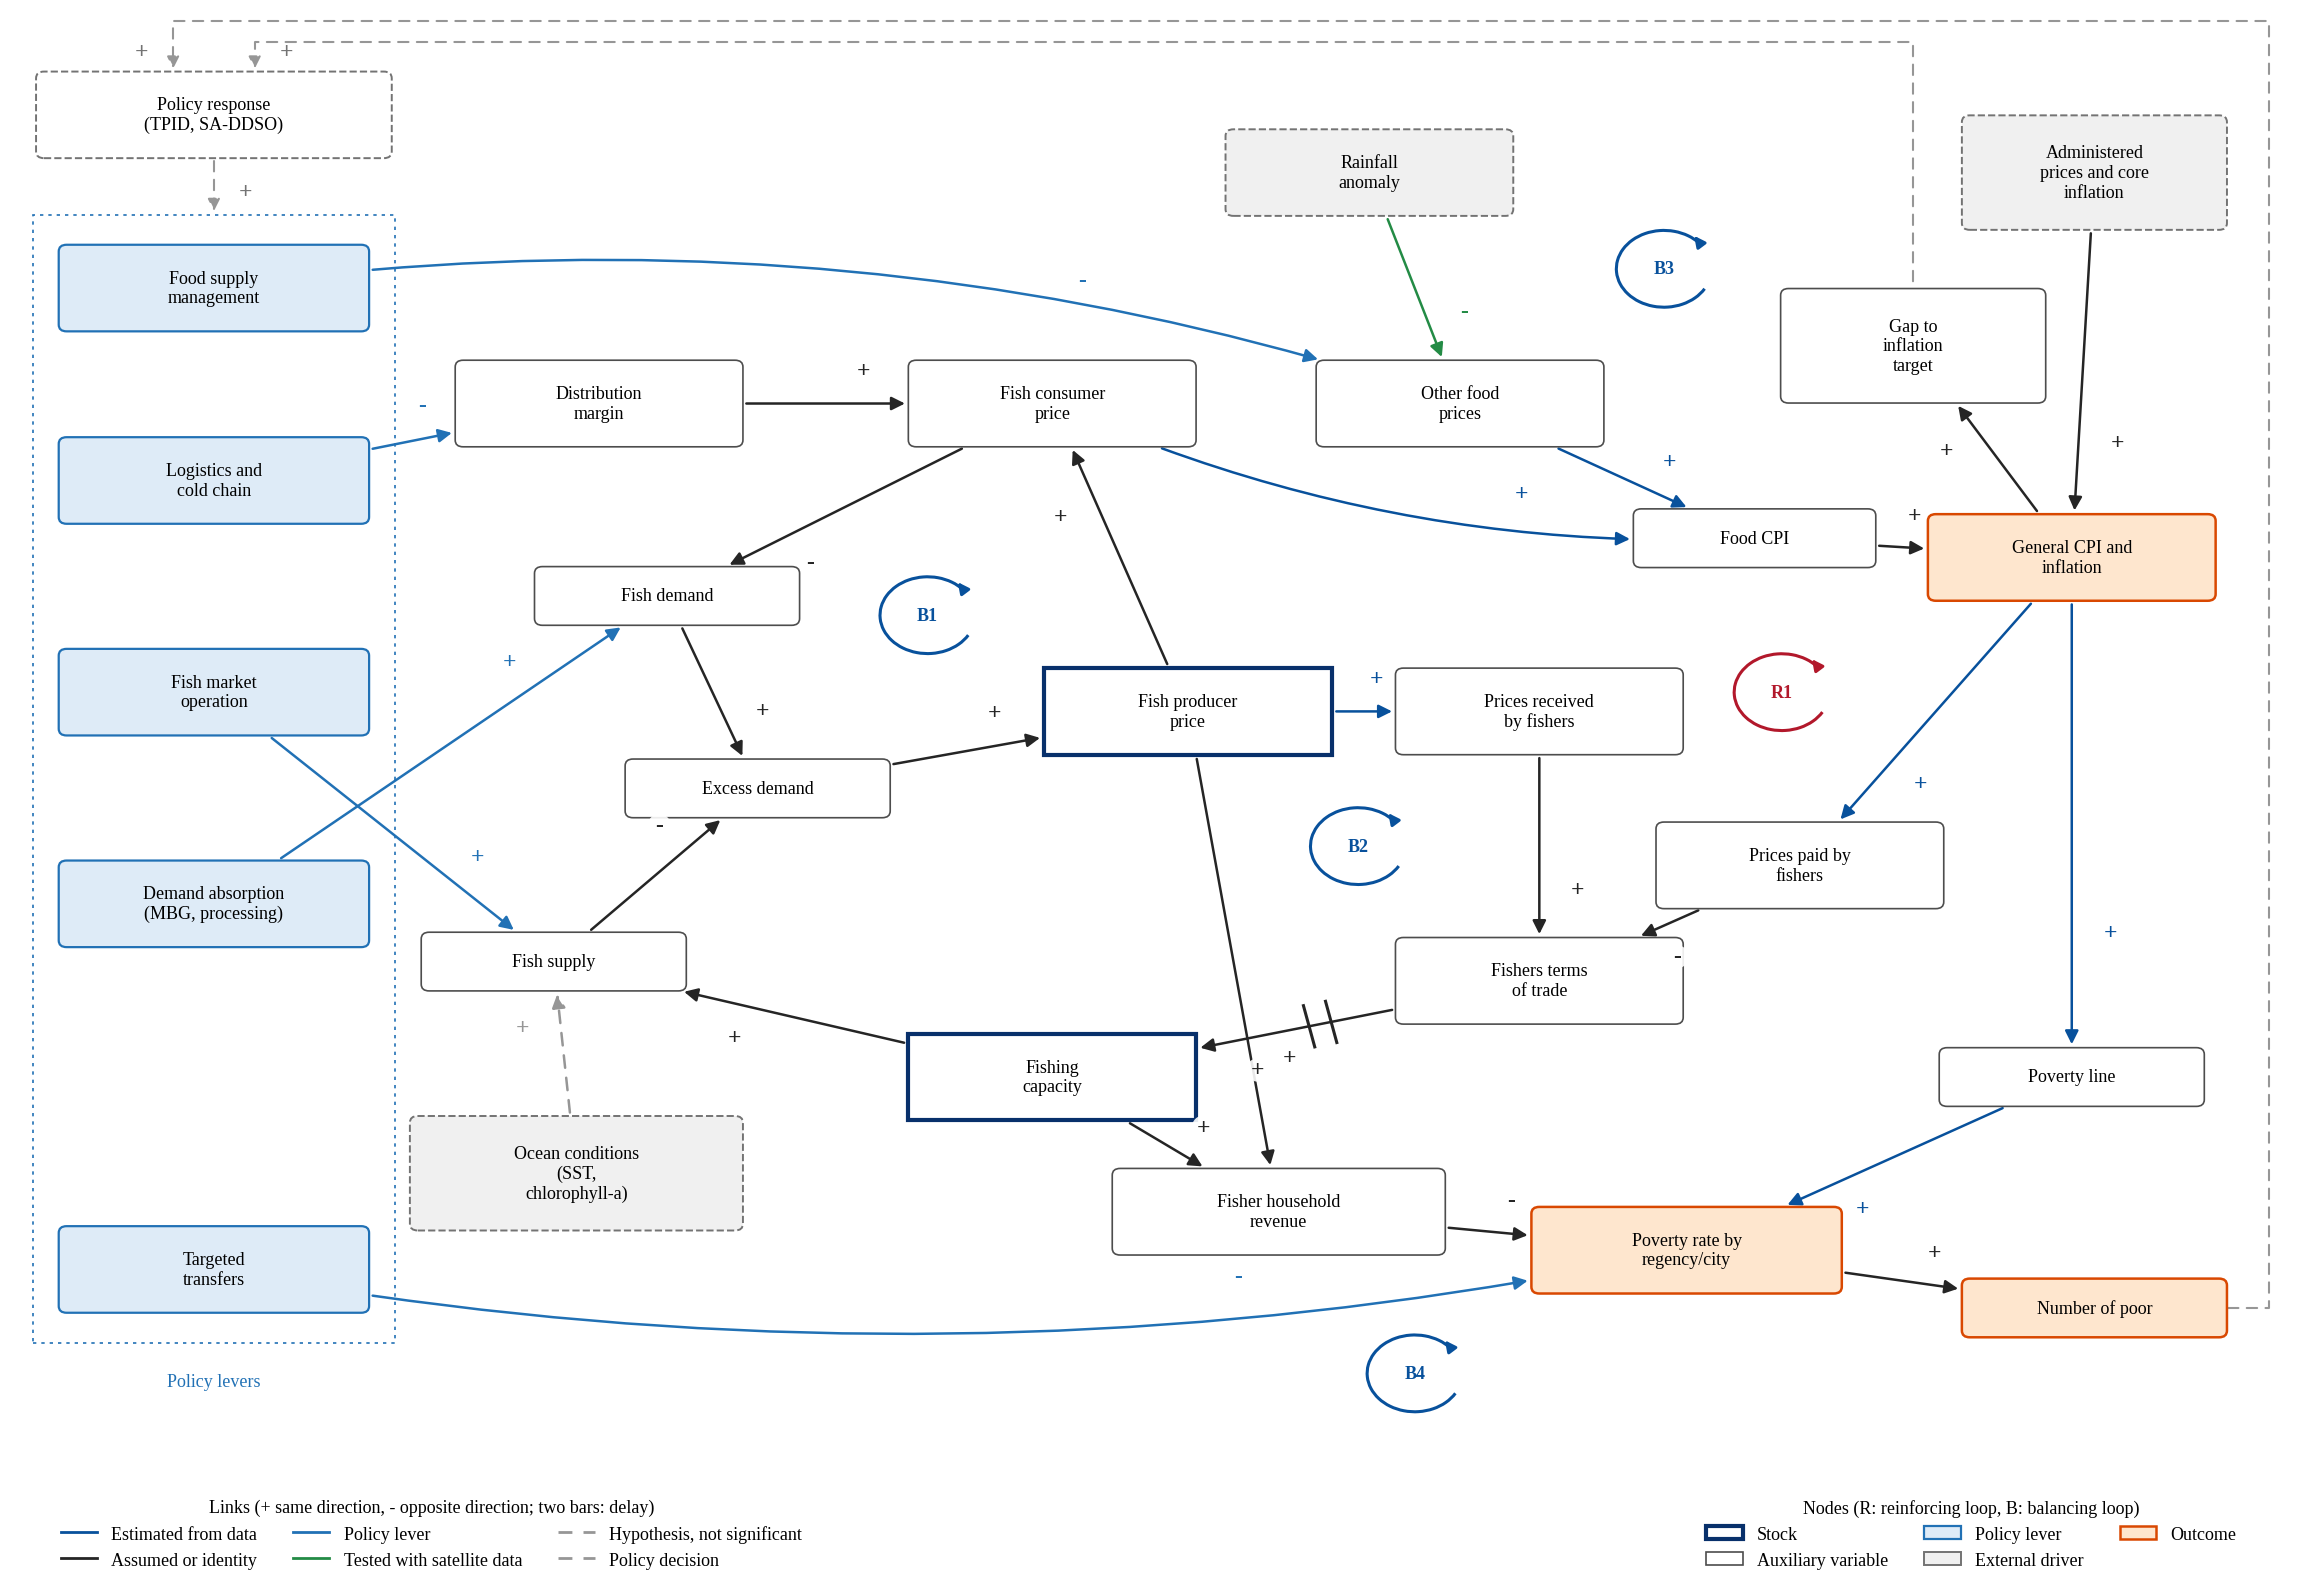

In [4]:
GAYA = {'stock': dict(fc='#ffffff', ec='#08306b', lw=3.0, box='square,pad=0.35'), 'aux': dict(fc='#ffffff', ec='#4d4d4d', lw=1.2, box='round,pad=0.35'),
        'policy': dict(fc='#deebf7', ec='#2171b5', lw=1.6, box='round,pad=0.35'), 'external': dict(fc='#f0f0f0', ec='#737373', lw=1.4, box='round,pad=0.35'),
        'outcome': dict(fc='#fee6ce', ec='#d94801', lw=1.8, box='round,pad=0.35'), 'decision': dict(fc='#ffffff', ec='#737373', lw=1.4, box='round,pad=0.35')}
WARNA_TAUTAN = {'estimated': '#08519c', 'assumed': '#252525', 'identity': '#252525', 'policy': '#2171b5', 'satellite_tested': '#238b45', 'hypothesis': '#969696', 'decision': '#969696'}
GARIS = {'hypothesis': (0, (5, 4)), 'decision': (0, (5, 4))}

fig = plt.figure(figsize=(23, 16))
ax = fig.add_axes([0.005, 0.1, 0.99, 0.89])
ax.set_xlim(0, 100.5); ax.set_ylim(-1.5, 72.5); ax.axis('off')
kotak = {}
for k, n in SIMPUL.items():
    g = GAYA[n['kind']]
    teks = textwrap.fill(n['en'], 17 if n['w'] >= 13 else 15)
    baris = teks.count('\n') + 1
    h = 0.9 + 1.45 * baris
    n['h'] = h
    p = FancyBboxPatch((n['x'] - n['w'] / 2, n['y'] - h / 2), n['w'], h, boxstyle=g['box'], fc=g['fc'], ec=g['ec'], lw=g['lw'],
                       ls='--' if n['kind'] in ('external', 'decision') else '-', zorder=3)
    ax.add_patch(p)
    ax.text(n['x'], n['y'], teks, ha='center', va='center', fontsize=13, zorder=4)
    kotak[k] = p
bingkai = Rectangle((1.0, 3.2), 16, 58.6, fill=False, ec='#2171b5', lw=1.2, ls=(0, (2, 3)), zorder=1)
ax.add_patch(bingkai)
ax.text(9, 1.2, 'Policy levers', ha='center', va='center', fontsize=13, color='#2171b5', zorder=4)

def titik_bezier(a, b, rad, t):
    (x1, y1), (x2, y2) = a, b
    cx, cy = (x1 + x2) / 2 + rad * (y2 - y1), (y1 + y2) / 2 - rad * (x2 - x1)
    return ((1 - t) ** 2 * x1 + 2 * (1 - t) * t * cx + t ** 2 * x2, (1 - t) ** 2 * y1 + 2 * (1 - t) * t * cy + t ** 2 * y2)

for a, b, tanda, bukti, mek, par, rad in TAUTAN:
    A, B = SIMPUL[a], SIMPUL[b]
    warna, ls = WARNA_TAUTAN[bukti], GARIS.get(bukti, '-')
    ar = FancyArrowPatch((A['x'], A['y']), (B['x'], B['y']), patchA=kotak[a], patchB=kotak[b], arrowstyle='-|>', mutation_scale=20,
                         connectionstyle=f'arc3,rad={rad}', lw=1.8, color=warna, linestyle=ls, zorder=2, shrinkA=2, shrinkB=2)
    ax.add_patch(ar)
    dxy = np.array([B['x'] - A['x'], B['y'] - A['y']], float)
    nrm = np.array([-dxy[1], dxy[0]]) / (np.linalg.norm(dxy) + 1e-9)
    di_dalam = lambda n, x, y: abs(x - n['x']) <= n['w'] / 2 + 0.6 and abs(y - n['y']) <= n['h'] / 2 + 0.6
    tt = np.linspace(0, 1, 400)
    pts = [titik_bezier((A['x'], A['y']), (B['x'], B['y']), rad, t) for t in tt]
    t_keluar = next(t for t, (x, y) in zip(tt, pts) if not di_dalam(A, x, y))
    t_masuk = next(t for t, (x, y) in zip(tt[::-1], pts[::-1]) if not di_dalam(B, x, y))
    t_ = t_masuk - 0.25 * (t_masuk - t_keluar)
    sx, sy = titik_bezier((A['x'], A['y']), (B['x'], B['y']), rad, t_)
    ax.text(sx + 1.7 * nrm[0], sy + 1.7 * nrm[1], tanda, fontsize=17, fontweight='bold', ha='center', va='center', color=warna, zorder=5,
            bbox=dict(boxstyle='circle,pad=0.05', fc='white', ec='none', alpha=0.9))
    if (a, b) == ('NTN', 'K'):
        mx, my = titik_bezier((A['x'], A['y']), (B['x'], B['y']), rad, 0.45)
        u = dxy / np.linalg.norm(dxy)
        for off in (-0.5, 0.5):
            cx_, cy_ = mx + off * u[0], my + off * u[1]
            ax.plot([cx_ - 1.1 * nrm[0], cx_ + 1.1 * nrm[0]], [cy_ - 1.1 * nrm[1], cy_ + 1.1 * nrm[1]], color=warna, lw=2.2, zorder=5)
for (a, b), titik in RUTE.items():
    kode = [Path.MOVETO] + [Path.LINETO] * (len(titik) - 1)
    ar = FancyArrowPatch(path=Path(titik, kode), arrowstyle='-|>', mutation_scale=18, lw=1.5, color=WARNA_TAUTAN['decision'], linestyle=(0, (5, 4)), zorder=2)
    ax.add_patch(ar)
    x_, y_ = titik[-1]
    geser_x = {'GAP': 1.4, 'NP': -1.4, 'POL': 1.4}[a]
    ax.text(x_ + geser_x, y_ + (0.9 if a != 'POL' else 1.0), '+', fontsize=17, fontweight='bold', color='#737373', ha='center', va='center', zorder=5)
for lp in LOOP:
    r = 2.1
    warna = '#b2182b' if lp['type'] == 'Reinforcing' else '#08519c'
    ax.add_patch(Arc((lp['x'], lp['y']), 2 * r, 2 * r * 0.95, theta1=40, theta2=330, color=warna, lw=2.2, zorder=4))
    ang = np.deg2rad(40)
    hx, hy = lp['x'] + r * np.cos(ang), lp['y'] + r * 0.95 * np.sin(ang)
    ax.annotate('', xy=(hx - 0.35, hy + 0.55), xytext=(hx, hy), arrowprops=dict(arrowstyle='-|>', color=warna, lw=2.2, mutation_scale=16), zorder=4)
    ax.text(lp['x'], lp['y'], lp['id'], ha='center', va='center', fontsize=13, fontweight='bold', color=warna, zorder=5)
h1 = [Line2D([0], [0], color=WARNA_TAUTAN[k], lw=2, ls=GARIS.get(k, '-')) for k in ['estimated', 'assumed', 'policy', 'satellite_tested', 'hypothesis', 'decision']]
l1 = ['Estimated from data', 'Assumed or identity', 'Policy lever', 'Tested with satellite data', 'Hypothesis, not significant', 'Policy decision']
h2 = [FancyBboxPatch((0, 0), 1, 1, boxstyle=GAYA[k]['box'], fc=GAYA[k]['fc'], ec=GAYA[k]['ec'], lw=GAYA[k]['lw']) for k in ['stock', 'aux', 'policy', 'external', 'outcome']]
l2 = ['Stock', 'Auxiliary variable', 'Policy lever', 'External driver', 'Outcome']
leg1 = fig.legend(h1, l1, loc='lower left', bbox_to_anchor=(0.02, 0.005), ncol=3, frameon=False, title='Links (+ same direction, - opposite direction; two bars: delay)')
leg2 = fig.legend(h2, l2, loc='lower right', bbox_to_anchor=(0.98, 0.005), ncol=3, frameon=False, title='Nodes (R: reinforcing loop, B: balancing loop)')
fig.savefig(os.path.join(SUB['figures'], 'D01_causal_loop_diagram.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

## Langkah 5. Tabel tautan, tabel loop, dan paket keluaran

In [5]:
JENIS = {'estimated': 'Estimated from data', 'assumed': 'Assumed, tested in sensitivity analysis', 'identity': 'Identity or definition', 'policy': 'Policy lever',
         'satellite_tested': 'Tested with satellite data (significant)', 'hypothesis': 'Hypothesis (not significant in satellite test)'}
D01 = pd.DataFrame([{'From': SIMPUL[a]['en'], 'To': SIMPUL[b]['en'], 'Polarity': tanda, 'Mechanism': mek, 'Evidence': JENIS[bukti], 'Parameter or statistic': par}
                    for a, b, tanda, bukti, mek, par, rad in TAUTAN] +
                   [{'From': SIMPUL[a]['en'] if a != 'POL' else SIMPUL['POL']['en'], 'To': SIMPUL['POL']['en'] if b == 'POL' else 'Policy levers', 'Polarity': '+',
                     'Mechanism': 'Decision rule closing the policy loop', 'Evidence': 'Policy decision', 'Parameter or statistic': 'set by the user or by SA-DDSO'}
                    for (a, b) in RUTE])
D02 = pd.DataFrame([{'Loop': lp['id'], 'Type': lp['type'], 'Path': ' to '.join(SIMPUL[k]['en'] for k in lp['path']), 'Interpretation': lp['en']} for lp in LOOP])
for kode, df in [('D01_links', D01), ('D02_loops', D02)]:
    df.to_csv(os.path.join(SUB['tables'], f'{kode}.csv'), index=False, encoding='utf-8')
with pd.ExcelWriter(os.path.join(OUT_DIR, 'tables_diagram.xlsx')) as xw:
    D01.to_excel(xw, sheet_name='D01_links', index=False)
    D02.to_excel(xw, sheet_name='D02_loops', index=False)
display(D01)
display(D02)
n_est = sum(1 for t in TAUTAN if t[3] == 'estimated')
tafsir('D01', f"Diagram memuat {len(SIMPUL)} simpul dan {len(TAUTAN) + len(RUTE)} tautan, dengan dua stok (harga produsen ikan dan kapasitas tangkap). "
       f"Sebanyak {n_est} tautan diestimasi dari data, termasuk elastisitas harga diterima nelayan terhadap harga produsen ({angka(teta, 3)}) dan elastisitas harga dibayar nelayan terhadap IHK ({angka(psi, 3)}). "
       f"Tautan curah hujan ke harga pangan lain {'didukung' if HUJAN_TERUJI else 'belum didukung'} data satelit"
       + (f" (korelasi {angka(B_HUJAN['r'], 2)} dengan perubahan harga cabai rawit, nilai p {angka(B_HUJAN['p'], 3)})" if B_HUJAN else '')
       + f", sedangkan tautan kondisi perairan ke pasokan ikan {'didukung' if LAUT_TERUJI else 'belum didukung'} data suhu laut dan klorofil-a, sehingga digambar {'garis penuh' if LAUT_TERUJI else 'putus-putus sebagai hipotesis'}. "
       f"Struktur ini membentuk empat loop penyeimbang (B1 penyesuaian harga, B2 respons pasokan, B3 kebijakan inflasi, B4 kebijakan kemiskinan) dan satu loop penguat (R1 tekanan biaya hidup nelayan). "
       f"Loop R1 menjelaskan mengapa inflasi pangan dapat berbalik menekan pasokan ikan: kenaikan harga konsumen menaikkan harga yang dibayar nelayan, menurunkan nilai tukar dan kapasitas tangkap, lalu mendorong harga ikan naik lagi.")
with open(os.path.join(SUB['interpretations'], 'interpretasi_otomatis_diagram.md'), 'w', encoding='utf-8') as f:
    f.write('# Interpretasi otomatis: diagram sistem dinamis\n\n')
    for k, daftar in TAFSIR.items():
        f.write(f'## {k}\n\n' + '\n\n'.join(daftar) + '\n\n')
zip_path = shutil.make_archive(os.path.join(BASE_DIR, 'output_forkestra2026_diagram'), 'zip', OUT_DIR)
print('Berkas ZIP:', zip_path)
if DI_COLAB:
    from google.colab import files
    files.download(zip_path)
else:
    from IPython.display import FileLink, display
    display(FileLink(os.path.relpath(zip_path)))

,From,To,Polarity,Mechanism,Evidence,Parameter or statistic
0,Logistics and cold chain,Distribution margin,-,Cold chain and logistics lower the distributio...,Policy lever,lever f up to 30 percent
1,Distribution margin,Fish consumer price,+,Margin is part of the consumer price,"Assumed, tested in sensitivity analysis",margin share 0.35
2,Fish producer price,Fish consumer price,+,Producer price is passed to consumers,Identity or definition,share 0.65
3,Fish consumer price,Fish demand,-,Higher consumer price lowers fish demand,"Assumed, tested in sensitivity analysis",price elasticity -0.80
4,"Demand absorption (MBG, processing)",Fish demand,+,MBG meals and processing plants add demand,Policy lever,lever a up to 15 percent
5,Fish demand,Excess demand,+,Excess demand is demand minus supply,Identity or definition,
6,Fish supply,Excess demand,-,Excess demand is demand minus supply,Identity or definition,
7,Excess demand,Fish producer price,+,Producer price rises when demand exceeds supply,"Assumed, tested in sensitivity analysis",adjustment speed 0.60
8,Fish market operation,Fish supply,+,Stock release adds to supply,Policy lever,lever s up to 10 percent
9,Fishing capacity,Fish supply,+,Capacity determines landed supply,Identity or definition,


,Loop,Type,Path,Interpretation
0,B1,Balancing,Fish producer price to Fish consumer price to ...,Price adjustment: a higher producer price rais...
1,B2,Balancing,Fish producer price to Prices received by fish...,Supply response: better prices for fishers exp...
2,R1,Reinforcing,Fish producer price to Fish consumer price to ...,Cost-of-living squeeze: higher consumer prices...
3,B3,Balancing,General CPI and inflation to Gap to inflation ...,Inflation policy: a gap above the target trigg...
4,B4,Balancing,Poverty rate by regency/city to Number of poor...,Poverty policy: a rising number of poor trigge...


Diagram memuat 27 simpul dan 33 tautan, dengan dua stok (harga produsen ikan dan kapasitas tangkap). Sebanyak 6
tautan diestimasi dari data, termasuk elastisitas harga diterima nelayan terhadap harga produsen (0,134) dan
elastisitas harga dibayar nelayan terhadap IHK (0,584). Tautan curah hujan ke harga pangan lain didukung data
satelit (korelasi -0,26 dengan perubahan harga cabai rawit, nilai p 0,020), sedangkan tautan kondisi perairan ke
pasokan ikan belum didukung data suhu laut dan klorofil-a, sehingga digambar putus-putus sebagai hipotesis.
Struktur ini membentuk empat loop penyeimbang (B1 penyesuaian harga, B2 respons pasokan, B3 kebijakan inflasi, B4
kebijakan kemiskinan) dan satu loop penguat (R1 tekanan biaya hidup nelayan). Loop R1 menjelaskan mengapa inflasi
pangan dapat berbalik menekan pasokan ikan: kenaikan harga konsumen menaikkan harga yang dibayar nelayan,
menurunkan nilai tukar dan kapasitas tangkap, lalu mendorong harga ikan naik lagi.

Berkas ZIP: /content/output_fo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Daftar pustaka

Forrester, J. W. (1961). *Industrial dynamics*. MIT Press.

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex world*. Irwin/McGraw-Hill.